# 5 Feature Selection

Because lag, rolling, momentum, and volatility features introduced missing values at the beginning of the dataset, we need to remove those incomplete rows so every feature has valid values.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

upload = files.upload()

Saving Engineered_Dataset.csv to Engineered_Dataset.csv


In [9]:
df_clean = pd.read_csv('Engineered_Dataset.csv')
df_clean.shape

(1899, 46)

In [10]:
# ===========================================
# Remove Missing Values After Feature Engineering
# ===========================================

# Shape before removing missing values
print("Shape before:", df_clean.shape)

# Remove rows with missing values
df_model = df_clean.dropna().reset_index(drop=True)

# Shape after removing missing values
print("Shape after :", df_model.shape)

# Verify that no missing values remain
print("\nRemaining Missing Values:")
print(df_model.isnull().sum().sum())

Shape before: (1899, 46)
Shape after : (1742, 46)

Remaining Missing Values:
0


In [11]:
# Display dataset information
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1742 entries, 0 to 1741
Data columns (total 46 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Daily Date                           1742 non-null   object 
 1   Share Code                           1742 non-null   object 
 2   Year High (GH¢)                      1742 non-null   float64
 3   Year Low (GH¢)                       1742 non-null   float64
 4   Previous Closing Price - VWAP (GH¢)  1742 non-null   float64
 5   Opening Price (GH¢)                  1742 non-null   float64
 6   Last Transaction Price (GH¢)         1742 non-null   float64
 7   Closing Price - VWAP (GH¢)           1742 non-null   float64
 8   Price Change (GH¢)                   1742 non-null   float64
 9   Total Shares Traded                  1742 non-null   float64
 10  Total Value Traded (GH¢)             1742 non-null   float64
 11  MA30                          

# One Importance Notice!!

Since we are *forecasting ETF prices using an Attention-Enhanced LSTM* using the close price as our tagret the we have to shift the current Closing price to one day ahead as Target to correctly capture one day future prediction.

In [33]:
# ===========================================
# Create Next-Day Prediction Target
# ===========================================

df_model["Target_Close"] = (
    df_model["Closing Price - VWAP (GH¢)"]
    .shift(-1)
)

# Remove the last row (no future target available)
df_model = df_model.dropna().reset_index(drop=True)

df_model.head()

,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,...,EMA12,EMA26,MACD,MACD_Signal,MACD_Histogram,Rolling_Volatility30,BB_Upper,BB_Lower,BB_Width,Target_Close
0,2018-10-17,MTNGH,0.93,0.75,0.89,0.89,0.90,0.9,0.01,35200.0,...,0.899135,0.867763,0.031372,0.036272,-0.004900,0.068114,0.974990,0.794010,0.180980,0.90
1,2018-10-18,MTNGH,0.93,0.75,0.90,0.90,0.89,0.9,0.00,66300.0,...,0.899268,0.870151,0.029117,0.034841,-0.005724,0.066358,0.970928,0.808072,0.162856,0.90
2,2018-10-19,MTNGH,0.93,0.75,0.90,0.90,0.89,0.9,0.00,500.0,...,0.899380,0.872362,0.027019,0.033276,-0.006258,0.064151,0.964229,0.824771,0.139458,0.90
3,2018-10-22,MTNGH,0.93,0.75,0.90,0.90,0.90,0.9,0.00,7000.0,...,0.899476,0.874409,0.025067,0.031634,-0.006568,0.061447,0.953195,0.845805,0.107390,0.90
4,2018-10-23,MTNGH,0.93,0.75,0.90,0.90,0.90,0.9,0.00,57000.0,...,0.899556,0.876305,0.023252,0.029958,-0.006706,0.058175,0.948326,0.856674,0.091652,0.91


In [34]:
print(df_model.shape)

df_model[[
    "Daily Date",
    "Closing Price - VWAP (GH¢)",
    "Target_Close"
]].tail()

(1740, 47)


,Daily Date,Closing Price - VWAP (GH¢),Target_Close
1735,2026-05-20,6.72,6.73
1736,2026-05-21,6.73,6.73
1737,2026-05-22,6.73,6.73
1738,2026-05-25,6.73,6.51
1739,2026-05-26,6.51,6.51


In [35]:
# ===========================================
# 5.1 Correlation Matrix
# ===========================================

# Select only numerical columns
numeric_df = df_model.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

corr_matrix.round(3)

,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢),MA30,...,EMA12,EMA26,MACD,MACD_Signal,MACD_Histogram,Rolling_Volatility30,BB_Upper,BB_Lower,BB_Width,Target_Close
Year High (GH¢),1.000,0.953,0.995,0.995,0.995,0.995,0.074,0.022,0.181,0.995,...,0.997,0.996,0.606,0.649,0.020,0.779,0.994,0.983,0.702,0.993
Year Low (GH¢),0.953,1.000,0.955,0.955,0.956,0.956,0.075,0.024,0.176,0.954,...,0.955,0.956,0.572,0.598,0.058,0.707,0.949,0.945,0.652,0.954
Previous Closing Price - VWAP (GH¢),0.995,0.955,1.000,1.000,0.999,1.000,0.074,0.022,0.180,0.993,...,0.998,0.996,0.649,0.678,0.069,0.780,0.992,0.982,0.700,0.997
Opening Price (GH¢),0.995,0.955,1.000,1.000,0.999,1.000,0.074,0.022,0.180,0.993,...,0.998,0.996,0.649,0.678,0.069,0.780,0.992,0.982,0.700,0.997
Last Transaction Price (GH¢),0.995,0.956,0.999,0.999,1.000,1.000,0.086,0.021,0.177,0.992,...,0.997,0.995,0.648,0.674,0.076,0.779,0.992,0.981,0.701,0.997
Closing Price - VWAP (GH¢),0.995,0.956,1.000,1.000,1.000,1.000,0.086,0.021,0.177,0.992,...,0.997,0.995,0.649,0.675,0.077,0.779,0.992,0.981,0.701,0.997
Price Change (GH¢),0.074,0.075,0.074,0.074,0.086,0.086,1.000,-0.018,-0.038,0.072,...,0.071,0.071,0.052,0.011,0.129,0.043,0.070,0.066,0.059,0.091
Total Shares Traded,0.022,0.024,0.022,0.022,0.021,0.021,-0.018,1.000,0.868,0.020,...,0.024,0.022,0.063,0.050,0.050,0.065,0.028,0.013,0.063,0.021
Total Value Traded (GH¢),0.181,0.176,0.180,0.180,0.177,0.177,-0.038,0.868,1.000,0.175,...,0.183,0.179,0.202,0.207,0.033,0.212,0.188,0.165,0.190,0.175
MA30,0.995,0.954,0.993,0.993,0.992,0.992,0.072,0.020,0.175,1.000,...,0.997,0.999,0.566,0.619,-0.018,0.750,0.992,0.992,0.670,0.992


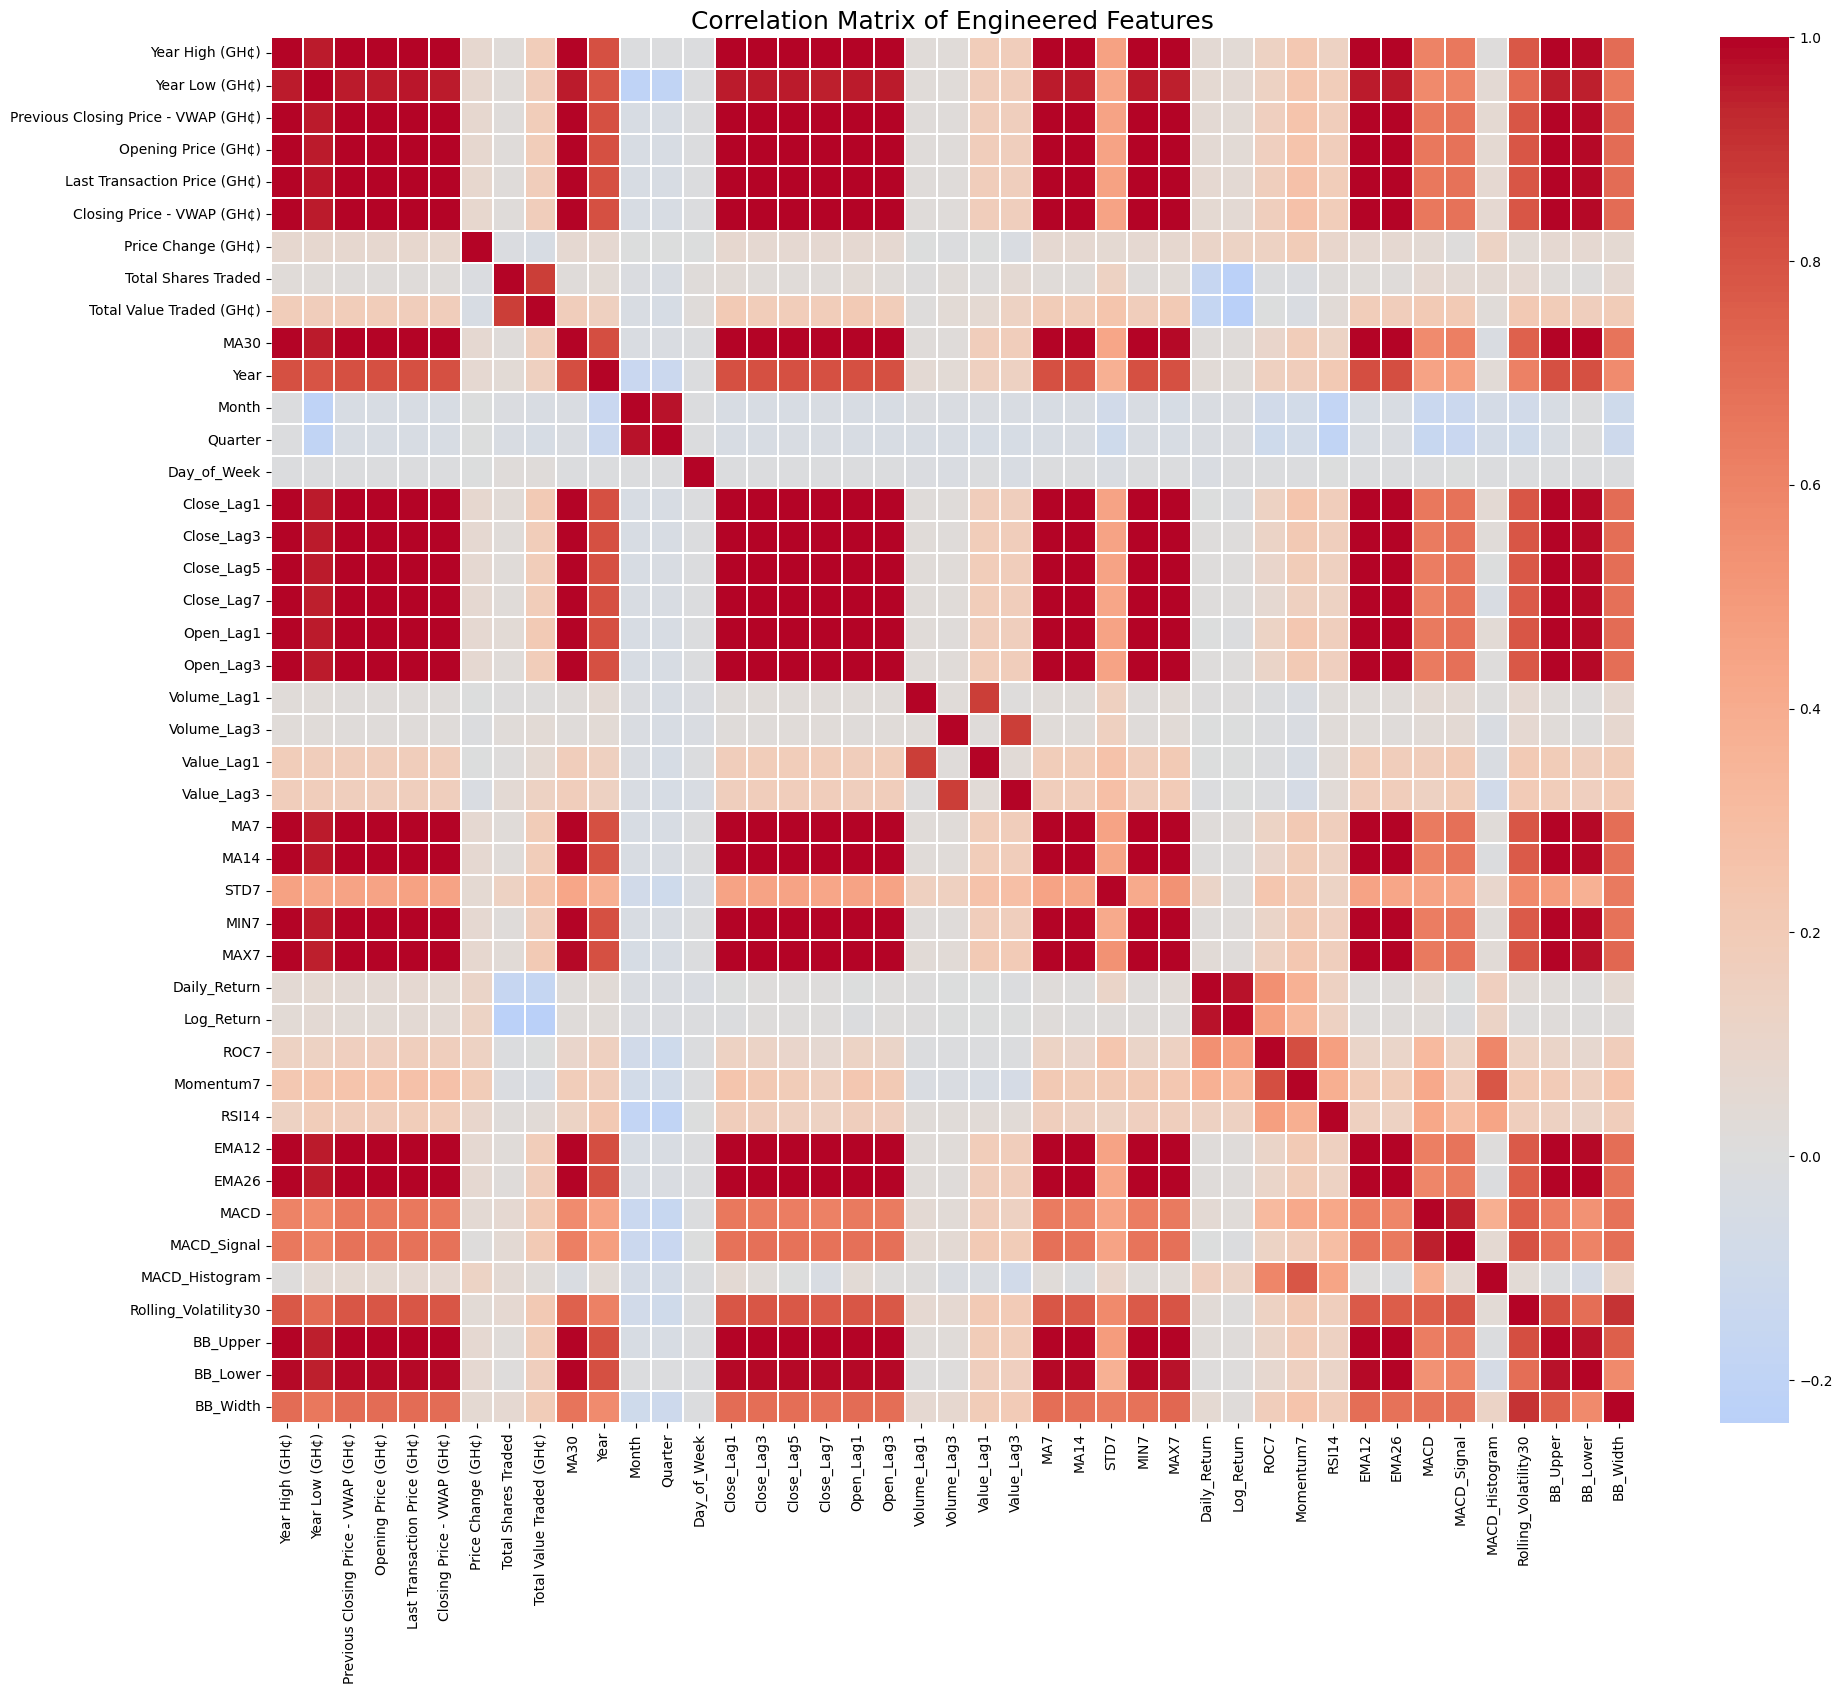

In [14]:
# ===========================================
# Correlation Heatmap
# ===========================================

plt.figure(figsize=(22,18))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3
)

plt.title("Correlation Matrix of Engineered Features", fontsize=18)

plt.show()

In [36]:
# ===========================================
# Correlation with Target
# ===========================================

target_corr = (
    corr_matrix["Target_Close"]
    .sort_values(ascending=False)
)

target_corr

,Target_Close
Target_Close,1.000000
Last Transaction Price (GH¢),0.997417
Closing Price - VWAP (GH¢),0.997414
Opening Price (GH¢),0.996699
Previous Closing Price - VWAP (GH¢),0.996699
Close_Lag1,0.996686
MA7,0.996649
EMA12,0.996192
Open_Lag1,0.995871
MIN7,0.995221


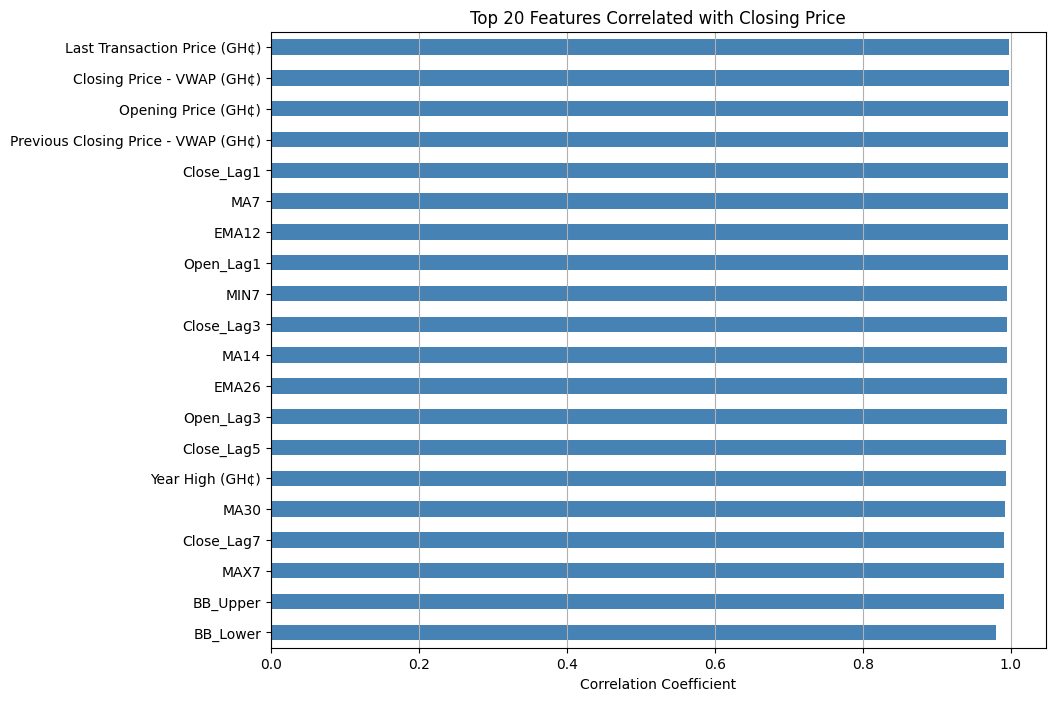

In [37]:
# ===========================================
# Top Correlated Features
# ===========================================

top_corr = target_corr.drop(
    "Target_Close"
).head(20)

plt.figure(figsize=(10,8))

top_corr.sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.xlabel("Correlation Coefficient")
plt.title("Top 20 Features Correlated with Closing Price")

plt.grid(axis='x')

plt.show()

In [38]:
# ===========================================
# Highly Correlated Features
# ===========================================

corr_pairs = (
    corr_matrix.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[
    corr_pairs < 1
]

high_corr = corr_pairs[
    corr_pairs > 0.95
]

high_corr.head(50)

,,0
Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),0.999999
Opening Price (GH¢),Previous Closing Price - VWAP (GH¢),0.999999
Closing Price - VWAP (GH¢),Last Transaction Price (GH¢),0.999862
Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),0.999862
EMA12,MA14,0.999647
MA14,EMA12,0.999647
MA7,EMA12,0.999637
EMA12,MA7,0.999637
Close_Lag1,Open_Lag1,0.999535
Open_Lag1,Close_Lag1,0.999535


# 5.1 Correlation Analysis

## Observation

A correlation analysis was performed to examine the relationships between the engineered predictor variables and the forecasting target, **Target_Close**, representing the next trading day's closing price. The results indicate that historical price variables exhibit the strongest linear relationships with the target. In particular, the **Last Transaction Price**, **Closing Price - VWAP**, **Opening Price**, and **Previous Closing Price** recorded correlation coefficients greater than 0.99, demonstrating that the most recent market prices are highly informative for forecasting the subsequent trading day's closing price.

Among the engineered features, lagged closing prices, moving averages (MA7, MA14, and MA30), exponential moving averages (EMA12 and EMA26), Bollinger Bands, and rolling minimum and maximum prices also exhibited very strong positive correlations with the target variable. In contrast, trading volume, return-based indicators, and calendar-related variables showed relatively weaker correlations, indicating that they contribute additional contextual information rather than serving as primary predictors.

---

## Interpretation

The correlation analysis confirms that **recent historical price information is the strongest predictor of the next trading day's closing price**, reflecting the temporal continuity commonly observed in financial time-series data. The strong relationships observed among lagged prices, moving averages, and exponential moving averages indicate that these engineered features successfully capture short-term and medium-term market trends that are relevant for forecasting future prices.

Although several predictors exhibit substantial correlations with one another, these relationships are expected because many technical indicators are derived from the same underlying price series. Rather than indicating a flaw in the feature engineering process, the high correlations demonstrate that the engineered variables effectively represent different aspects of historical market behaviour. These findings provide an initial assessment of predictor relevance and will be complemented by Variance Inflation Factor (VIF) analysis and Random Forest feature importance before determining the final feature set for the proposed Attention-LSTM forecasting model.

#5.2 Variance Inflation Factor (VIF)
Objective

While correlation measures the relationship between two variables, VIF measures how much the variance of a predictor is inflated because of its relationship with all the other predictors. This provides a more comprehensive assessment of multicollinearity.

Since our dataset contains many engineered variables derived from historical prices, high VIF values are expected. However, the analysis will help identify redundant predictors and guide feature selection.

In [18]:
# ===========================================
# 5.2 Variance Inflation Factor (VIF)
# ===========================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [39]:
# ===========================================
# Prepare Predictor Variables
# ===========================================
'''
The droped column are non numeric and not intednded as predictors
'''

X_vif = df_model.drop(columns=[
    "Daily Date",
    "Share Code",
    "Month_Name",
    "Target_Close",

])

X_vif.head()

,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢),MA30,...,RSI14,EMA12,EMA26,MACD,MACD_Signal,MACD_Histogram,Rolling_Volatility30,BB_Upper,BB_Lower,BB_Width
0,0.93,0.75,0.89,0.89,0.90,0.9,0.01,35200.0,31680.0,0.845333,...,63.157895,0.899135,0.867763,0.031372,0.036272,-0.004900,0.068114,0.974990,0.794010,0.180980
1,0.93,0.75,0.90,0.90,0.89,0.9,0.00,66300.0,59670.0,0.850333,...,56.250000,0.899268,0.870151,0.029117,0.034841,-0.005724,0.066358,0.970928,0.808072,0.162856
2,0.93,0.75,0.90,0.90,0.89,0.9,0.00,500.0,450.0,0.855333,...,46.153846,0.899380,0.872362,0.027019,0.033276,-0.006258,0.064151,0.964229,0.824771,0.139458
3,0.93,0.75,0.90,0.90,0.90,0.9,0.00,7000.0,6300.0,0.860333,...,41.666667,0.899476,0.874409,0.025067,0.031634,-0.006568,0.061447,0.953195,0.845805,0.107390
4,0.93,0.75,0.90,0.90,0.90,0.9,0.00,57000.0,51300.0,0.865333,...,50.000000,0.899556,0.876305,0.023252,0.029958,-0.006706,0.058175,0.948326,0.856674,0.091652


In [40]:
# ===========================================
# Calculate VIF
# ===========================================

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
5,Closing Price - VWAP (GH¢),inf
40,BB_Upper,inf
17,Close_Lag7,inf
34,EMA12,inf
41,BB_Lower,inf
35,EMA26,inf
36,MACD,9.007199e+15
42,BB_Width,3.002400e+15
32,Momentum7,4.740631e+14
37,MACD_Signal,1.838204e+14


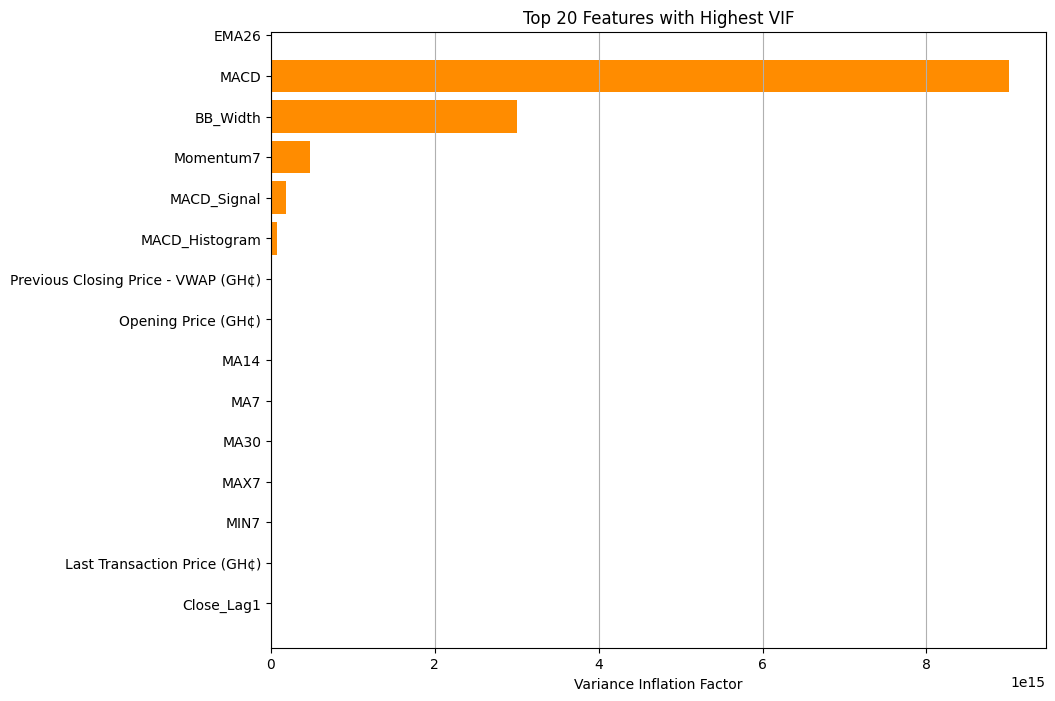

In [41]:
# ===========================================
# Top 20 Highest VIF
# ===========================================

top_vif = vif.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_vif["Feature"],
    top_vif["VIF"],
    color="darkorange"
)

plt.xlabel("Variance Inflation Factor")
plt.title("Top 20 Features with Highest VIF")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.show()

In [42]:
# ===========================================
# VIF Categories
# ===========================================

def classify_vif(value):
    if value < 5:
        return "Low"
    elif value < 10:
        return "Moderate"
    else:
        return "High"

vif["Category"] = vif["VIF"].apply(classify_vif)

vif

,Feature,VIF,Category
5,Closing Price - VWAP (GH¢),inf,High
40,BB_Upper,inf,High
17,Close_Lag7,inf,High
34,EMA12,inf,High
41,BB_Lower,inf,High
35,EMA26,inf,High
36,MACD,9.007199e+15,High
42,BB_Width,3.002400e+15,High
32,Momentum7,4.740631e+14,High
37,MACD_Signal,1.838204e+14,High


# 5.2 Variance Inflation Factor (VIF)

## Observation

Variance Inflation Factor (VIF) analysis was conducted using the predictor variables for forecasting the next trading day's closing price (`Target_Close`). The target variable was excluded from the analysis, while all historical price variables and engineered technical indicators were retained as predictors.

The analysis revealed substantial multicollinearity among several price-based variables and engineered technical indicators. In particular, the current day's **Closing Price - VWAP (GH¢)**, **EMA12**, **EMA26**, **Close_Lag7**, and the Bollinger Band indicators exhibited extremely large or infinite VIF values. Similarly, moving averages, lagged prices, and MACD-related features produced exceptionally high VIF values, reflecting the strong dependence among variables derived from the same historical price series.

Conversely, variables such as **Price Change**, **Day_of_Week**, **Total Shares Traded**, and the lagged trading volume variables displayed comparatively low VIF values, indicating relatively weak multicollinearity with the remaining predictors.

---

## Interpretation

The high VIF values are expected because many of the engineered features are mathematically derived from the historical closing price and therefore contain overlapping information. Moving averages, exponential moving averages, Bollinger Bands, lagged prices, and MACD indicators are all constructed from the same underlying price sequence, naturally resulting in strong multicollinearity.

Importantly, the presence of high multicollinearity does not invalidate these predictors for the proposed Attention-LSTM model. Unlike traditional linear regression models, sequence-based deep learning architectures are designed to learn complex nonlinear relationships from correlated temporal features. Consequently, the VIF analysis is used to identify redundancy rather than as the sole criterion for feature elimination.

The VIF results therefore complement the correlation analysis by confirming the expected dependence among technical indicators while supporting the retention of informative temporal features for next-day stock price forecasting. Final feature selection will be guided by the combined evidence from correlation analysis, VIF assessment, and Random Forest feature importance.

#5.3 Random Forest Feature Importance

Unlike correlation and VIF, which examine relationships among variables, Random Forest evaluates how much each feature actually contributes to predicting the target variable. This makes it particularly valuable for identifying informative predictors in a nonlinear setting.

In [43]:
# ===========================================
# 5.3 Random Forest Feature Importance
# ===========================================

from sklearn.ensemble import RandomForestRegressor

# Predictor variables
X = df_model.drop(columns=[
    "Daily Date",
    "Share Code",
    "Month_Name",
    "Target_Close"
])

# Target variable
y = df_model["Target_Close"]

print(X.shape)
print(y.shape)

(1740, 43)
(1740,)


In [44]:
# ===========================================
# Train Random Forest
# ===========================================

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [45]:
# ===========================================
# Feature Importance
# ===========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
41,BB_Lower,0.324515
24,MA7,0.094695
35,EMA26,0.086738
25,MA14,0.067864
0,Year High (GH¢),0.054313
5,Closing Price - VWAP (GH¢),0.053365
9,MA30,0.052109
27,MIN7,0.050171
34,EMA12,0.040897
4,Last Transaction Price (GH¢),0.038255


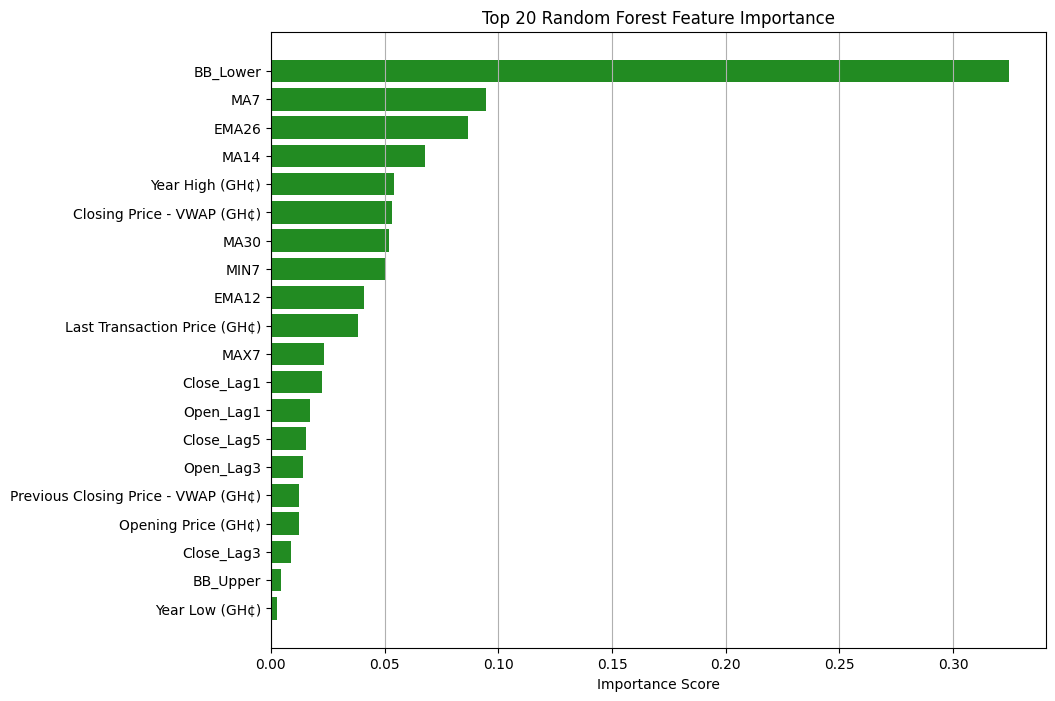

In [46]:
# ===========================================
# Top 20 Features
# ===========================================

top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"],
    color="forestgreen"
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.title("Top 20 Random Forest Feature Importance")

plt.grid(axis="x")

plt.show()

In [47]:
importance["Importance (%)"] = (
    importance["Importance"] * 100
)

importance.head(20)

,Feature,Importance,Importance (%)
41,BB_Lower,0.324515,32.451534
24,MA7,0.094695,9.469466
35,EMA26,0.086738,8.673829
25,MA14,0.067864,6.786357
0,Year High (GH¢),0.054313,5.431270
5,Closing Price - VWAP (GH¢),0.053365,5.336477
9,MA30,0.052109,5.210888
27,MIN7,0.050171,5.017081
34,EMA12,0.040897,4.089744
4,Last Transaction Price (GH¢),0.038255,3.825471


# 5.3 Random Forest Feature Importance

## Observation

A Random Forest Regressor was trained using the engineered predictor variables to estimate their relative importance for forecasting the **next trading day's closing price (`Target_Close`)**. The resulting feature importance scores indicate that the **Lower Bollinger Band (BB_Lower)** is the most influential predictor, contributing approximately **32.45%** of the model's predictive importance. Other highly ranked predictors include **MA7**, **EMA26**, **MA14**, **Year High**, **Closing Price - VWAP**, **MA30**, **MIN7**, **EMA12**, and **Last Transaction Price**, all of which represent historical price trends and technical market indicators.

Several lagged price variables, including **Close_Lag1**, **Close_Lag3**, **Close_Lag5**, **Open_Lag1**, and **Open_Lag3**, also demonstrated meaningful predictive contributions, confirming that recent trading history contains valuable information for forecasting future prices. In contrast, calendar variables, trading volume variables, return-based indicators, and momentum measures exhibited relatively low importance scores, suggesting that they play a comparatively minor role in predicting the next trading day's closing price.

---

## Interpretation

The Random Forest feature importance analysis demonstrates that **technical indicators derived from historical price movements are more informative for forecasting the next trading day's closing price than raw trading activity or calendar-based variables**. Indicators such as Bollinger Bands, moving averages, exponential moving averages, and lagged prices effectively capture short-term market trends, price momentum, and support-resistance behaviour that influence subsequent price movements.

The relatively lower importance assigned to trading volume, return-based indicators, and calendar features suggests that these variables provide complementary contextual information rather than serving as primary forecasting signals. Importantly, the feature importance rankings differ from those obtained when predicting the current day's closing price, highlighting the effect of reformulating the problem as a genuine one-step-ahead forecasting task.

The Random Forest results therefore provide an objective ranking of predictor relevance for next-day stock price forecasting and, together with the correlation and VIF analyses, form the basis for selecting the final predictor set used to train the proposed Attention-Enhanced Long Short-Term Memory (Attention-LSTM) model.


---



In [48]:
df_model.to_csv('Final_Dataset.csv', index=False)